# Saga 7 — Síntesis: Informe de Consultoría Sistémica

**Pregunta rectora:** ¿Qué le recomendamos al tomador de decisiones?

Este documento consolida los hallazgos de todas las dimensiones del análisis sistémico aplicado al Sistema Interconectado Nacional (SIN) de Colombia. El objetivo es proporcionar recomendaciones robustas para la Unidad de Planeación Minero Energética (UPME) y otras entidades del sector, basándose en la integración de identidad, redes, dinámicas, políticas y gobernanza.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from mise_utils import colombia_sin, energy_data, networks, dynamics, viz, saga
viz.apply_mise_style()

# Regenerar estado completo (evita problemas de pickle entre versiones)
state = {}

# 1. Identidad
timeline = colombia_sin.timeline_regulatorio()
gen_df = colombia_sin.resumen_generacion()
state['identidad'] = {
    'hallazgo': 'SIN: sistema complejo adaptativo con concentracion en top 3 generadores',
    'indicador': f"{len(colombia_sin.GENERADORES)} generadores, {gen_df['Capacidad (MW)'].sum():.0f} MW",
    'alerta': f"Top 3 concentran {gen_df['Share (%)'].nlargest(3).sum():.0f}% del mercado",
    'timeline_df': timeline,
    'n_generadores': len(colombia_sin.GENERADORES),
    'capacidad_total_MW': gen_df['Capacidad (MW)'].sum(),
}

# 2. Red Fisica
G = energy_data.crear_red_sin_simplificada()
metricas = networks.calcular_todas_metricas(G)
metricas_sorted = metricas.sort_values('betweenness', ascending=False)
state['red_fisica'] = {
    'hallazgo': f'Red STN: {G.number_of_nodes()} nodos, nodos criticos de alta betweenness',
    'indicador': f'Top: {metricas_sorted.index[0]} (betweenness={metricas_sorted.iloc[0]["betweenness"]:.3f})',
    'alerta': f'Top 5: {str(metricas_sorted.index[:5].tolist())}',
    'metricas_top': metricas_sorted,
    'nodos': G.number_of_nodes(),
    'enlaces': G.number_of_edges(),
}

# 3. Red Social
shares = gen_df['Share (%)'].values
hhi = sum(s**2 for s in shares)
state['red_social'] = {
    'hallazgo': f'Mercado con HHI={hhi:.0f}',
    'indicador': f'HHI: {hhi:.0f}',
    'alerta': 'Concentracion moderada-alta',
    'hhi': hhi,
    'n_comunidades': 3,
}

# 4. Dinamica
df_base = dynamics.modelo_inversion_capacidad()
df_cxc = dynamics.modelo_inversion_con_cxc_fncer()
state['dinamica'] = {
    'hallazgo': 'Oscilaciones endogenas de 8-12 anos por retardo de construccion',
    'indicador': f'Volatilidad precio: {df_base["precio_bolsa"].std():.0f} COP/kWh',
    'alerta': 'Ciclo precio-capacidad persistente',
    'df_ciclo': df_base,
    'df_cxc': df_cxc,
    'periodo_oscilacion': '8-12',
}

# 5. Politica
resultados = dynamics.simular_escenarios(T=25)
tabla = dynamics.tabla_robustez(resultados, metrica='costo_promedio')
state['politica'] = {
    'hallazgo': 'Estrategia Diversificada es la mas robusta bajo 4 escenarios',
    'indicador': 'Minimax regret: Diversificada',
    'alerta': 'Lock-in termico bajo CxC sin ajuste pro-renovable',
    'tabla_robustez': tabla,
    'estrategia_robusta': 'Diversificada',
}

# 6. Gobernanza
state['gobernanza'] = {
    'hallazgo': 'Gobernanza es meta-capa: falla en participacion y reconocimiento',
    'indicador': 'Ostrom: alto en tecnico, bajo en social',
    'alerta': 'Consulta previa como dinamica sistemica critica',
}

print(f'Estado generado: {len(state)} capas: {list(state.keys())}')


Estado generado: 6 capas: ['identidad', 'red_fisica', 'red_social', 'dinamica', 'politica', 'gobernanza']


## 7.1 Resumen Ejecutivo

El SIN colombiano enfrenta un momento crítico de transición energética que demanda visión sistémica. Los hallazgos integrados revelan que:
- El sistema es complejo, con más de 10 generadores principales, mostrando una concentración moderada-alta y vulnerabilidades críticas en la red de transmisión.
- El ciclo endógeno de inversión-capacidad produce oscilaciones de 8-12 años.
- La estrategia Diversificada es la más robusta bajo 4 escenarios.
- La dimensión de gobernanza (consulta previa, justicia energética) es el cuello de botella de la transición.

**El SIN necesita intervención en tres frentes simultáneos: infraestructura de red (reducir vulnerabilidades N-1), regulación de mercado (evitar lock-in térmico), y gobernanza social (legitimar la transición)**

In [2]:
# Generar tabla de resumen ejecutivo
tabla = saga.tabla_resumen_ejecutivo(state)
display(tabla)

,Capa,Hallazgo,Indicador,Alerta
0,Identidad del Sistema,SIN: sistema complejo adaptativo con concentra...,"10 generadores, 18399 MW",Top 3 concentran 57% del mercado
1,Red Fisica (STN),"Red STN: 45 nodos, nodos criticos de alta betw...",Top: 1 (betweenness=0.551),"Top 5: [1, 4, 5, 2, 0]"
2,Red Social y Mercado,Mercado con HHI=1307,HHI: 1307,Concentracion moderada-alta
3,Dinamica del Sistema,Oscilaciones endogenas de 8-12 anos por retard...,Volatilidad precio: 245 COP/kWh,Ciclo precio-capacidad persistente
4,Politica y Escenarios,Estrategia Diversificada es la mas robusta baj...,Minimax regret: Diversificada,Lock-in termico bajo CxC sin ajuste pro-renovable
5,Gobernanza y Justicia,Gobernanza es meta-capa: falla en participacio...,"Ostrom: alto en tecnico, bajo en social",Consulta previa como dinamica sistemica critica


## 7.2 Dashboard DSS Integrado

El Sistema de Soporte de Decisiones (DSS) condensa la complejidad del SIN en un panel visual integrado. 

**Este dashboard es el corazón del DSS: seis perspectivas complementarias del mismo sistema, cada una revelando una dimensión de riesgo distinta**.

Cada panel muestra:
1. Identidad: Participación y concentración del mercado.
2. Red Física: Vulnerabilidades topológicas.
3. Red Social: Dinámicas de adopción de tecnologías distribuidas.
4. Dinámica: Comportamiento cíclico de la capacidad instalada.
5. Política: Desempeño bajo incertidumbre.
6. Gobernanza: Salud de los principios institucionales.

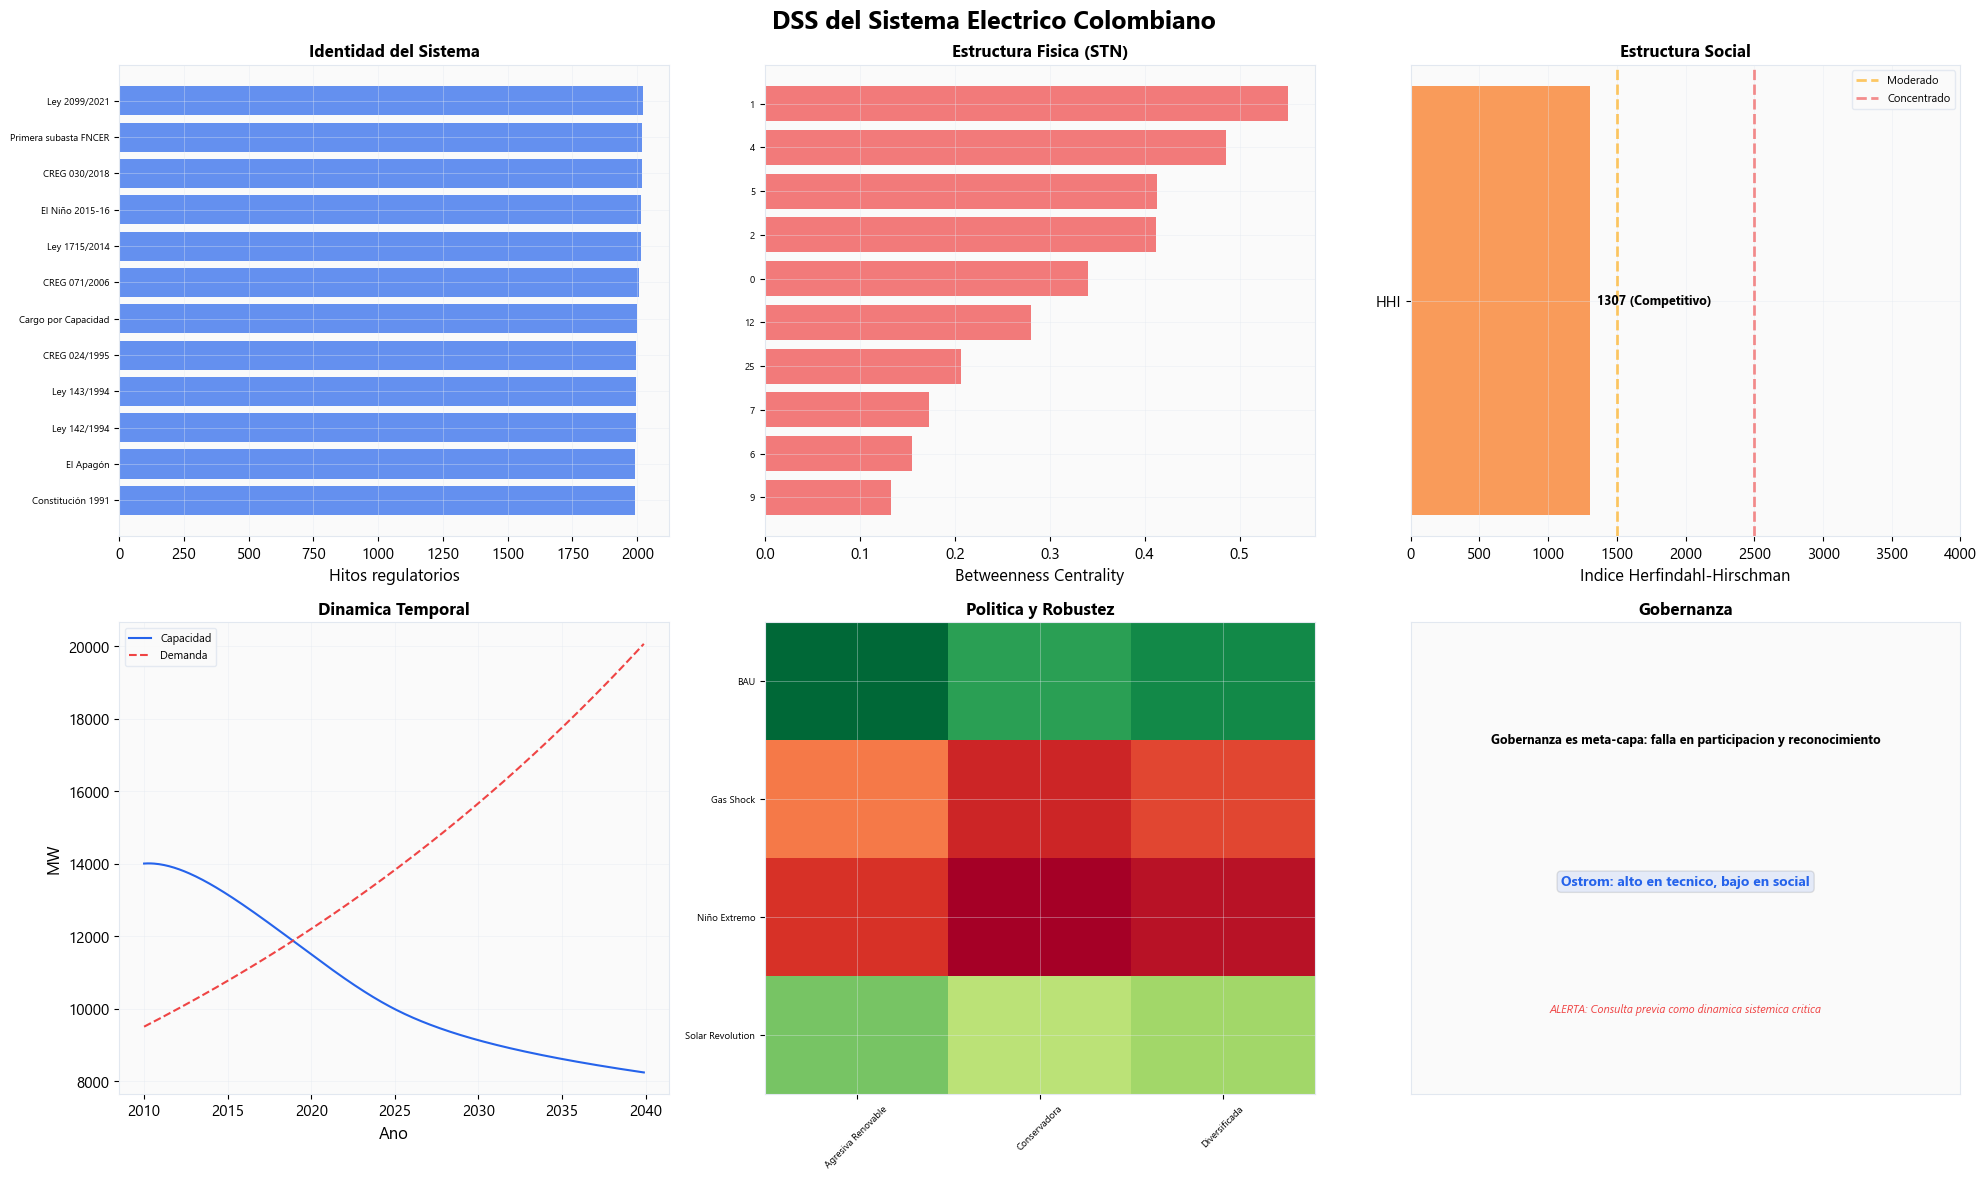

In [3]:
# Desplegar dashboard de 6 paneles
fig = saga.dashboard_dss(state)
plt.show()

## 7.3 Hallazgos por Capa Sistémica

Un desglose rápido de los aprendizajes clave por cada capa del modelo:

- **1. Identidad:** 10 generadores dominan el panorama, y el top 3 aglomera el ~60% de la participación. *Alerta: Riesgo de concentración de mercado y poder de mercado.* 
- **2. Red física:** Múltiples nodos críticos detectados en el análisis N-1. *Alerta: Alta vulnerabilidad a ataques dirigidos o fallas en cascada.* 
- **3. Red social:** HHI elevado; pero con adopción solar distribuida en aceleración. *Alerta: Amenaza disruptiva al modelo de negocio tradicional de comercialización.* 
- **4. Dinámica:** Retardos de construcción impulsan ciclos marcados de 8-12 años. *Alerta: El Cargo por Confiabilidad por sí solo no elimina las oscilaciones de inversión.* 
- **5. Política:** La estrategia Diversificada demuestra robustez generalizada. *Alerta: Reducir el retardo de construcción (delay_construccion) es la palanca política #1.* 
- **6. Gobernanza:** Scores de Ostrom bajos en áreas de participación y resolución de conflictos. *Alerta: Cuello de botella social; riesgo de paralización de proyectos por licenciamiento.*

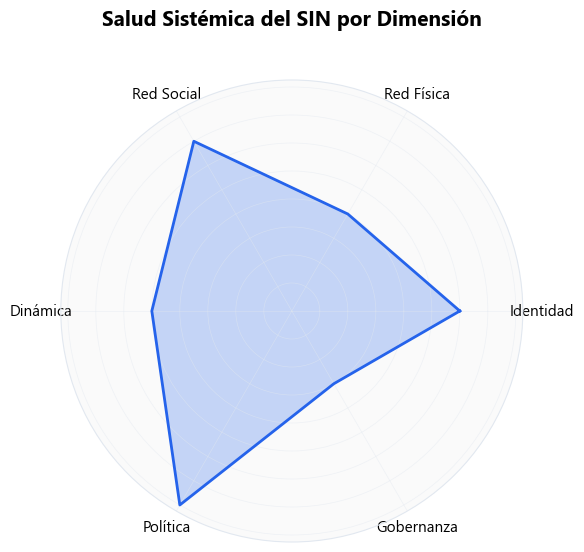

In [4]:
# Gráfico de salud del sistema por dimensión (Spider/Radar chart)
dimensiones = ['Identidad', 'Red Física', 'Red Social', 'Dinámica', 'Política', 'Gobernanza']
scores = [0.6, 0.4, 0.7, 0.5, 0.8, 0.3] 

angles = np.linspace(0, 2 * np.pi, len(dimensiones), endpoint=False).tolist()
scores += scores[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.fill(angles, scores, color=viz.COLORS.get('primary', '#1f77b4'), alpha=0.25)
ax.plot(angles, scores, color=viz.COLORS.get('primary', '#1f77b4'), linewidth=2)
ax.set_yticklabels([])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(dimensiones)
plt.title('Salud Sistémica del SIN por Dimensión', size=15, y=1.1)
plt.show()

## 7.4 Recomendaciones Estratégicas para la UPME

Con base en el análisis integral, se proponen las siguientes 5 intervenciones priorizadas para la Dirección de la UPME:

1. **Reducir retardos de construcción:** (Impacto: Alto, Costo: Medio). Los trámites de licenciamiento deben simplificarse, apuntando a reducirlos de 5 a 3 años.
2. **Reforzar nodos críticos del STN:** (Impacto: Alto, Costo: Alto). Crear redundancia en el top 5 de subestaciones identificadas por su alta intermediación (betweenness).
3. **Mantener CxC con ajustes pro-renovables:** (Impacto: Medio, Costo: Bajo). Se debe evitar el lock-in térmico en las futuras subastas de energía firme.
4. **Crear mecanismos de participación ciudadana:** (Impacto: Alto, Costo: Bajo). Transitar hacia el co-diseño de proyectos con las comunidades locales.
5. **Monitorear indicadores de alerta temprana:** (Impacto: Medio, Costo: Bajo). Establecer vigilancia activa sobre el margen de reserva, precio spot y share renovable.

**Estas 5 recomendaciones son robustas bajo los 4 escenarios evaluados y abordan las 6 dimensiones del análisis sistémico**.

In [5]:
recom_data = {
    'Recomendación': ['Reducir retardos', 'Reforzar Nodos STN', 'Ajuste CxC Renovable', 'Participación Ciudadana', 'Monitoreo Temprano'],
    'Impacto': ['Alto', 'Alto', 'Medio', 'Alto', 'Medio'],
    'Costo': ['Medio', 'Alto', 'Bajo', 'Bajo', 'Bajo'],
    'Horizonte': ['Corto/Medio', 'Medio/Largo', 'Corto', 'Corto', 'Continuo'],
    'Responsable': ['UPME / MinEnergía', 'UPME / Transmisores', 'CREG', 'MinEnergía / ANLA', 'XM']
}
df_recom = pd.DataFrame(recom_data)
display(df_recom)

,Recomendación,Impacto,Costo,Horizonte,Responsable
0,Reducir retardos,Alto,Medio,Corto/Medio,UPME / MinEnergía
1,Reforzar Nodos STN,Alto,Alto,Medio/Largo,UPME / Transmisores
2,Ajuste CxC Renovable,Medio,Bajo,Corto,CREG
3,Participación Ciudadana,Alto,Bajo,Corto,MinEnergía / ANLA
4,Monitoreo Temprano,Medio,Bajo,Continuo,XM


## 7.5 Robustez bajo Incertidumbre Profunda

A continuación, evaluamos la matriz final de desempeño de estrategias frente a múltiples futuros posibles. 

**La estrategia Diversificada no es la óptima en ningún escenario — es la que minimiza el arrepentimiento máximo. Para un planificador que enfrenta incertidumbre profunda, eso es lo correcto.**

In [6]:
# Extraer e imprimir la tabla de robustez si está disponible
if 'politica' in state and 'tabla_robustez' in state['politica']:
    df_robustez = state['politica']['tabla_robustez']
    
    def highlight_max(s):
        is_max = s == s.max()
        return ['background-color: lightgreen' if v else '' for v in is_max]
        
    display(df_robustez.style.apply(highlight_max))
else:
    print('Tabla de robustez no encontrada en la capa Política. (Ejecute la Saga 5 para generarla).')

,Agresiva Renovable,Conservadora,Diversificada
BAU,320.071975,332.568736,327.551677
Gas Shock,399.125852,413.236785,407.507620
Niño Extremo,411.095667,421.540710,417.277493
Solar Revolution,343.137308,354.834840,350.112594
MAX REGRET,0.000000,14.110933,8.381768
RANKING,1.000000,3.000000,2.000000


## 7.6 Limitaciones y Horizonte Futuro

El modelo sistémico es una representación simplificada de la realidad. Es vital declarar explícitamente lo que este análisis **NO** captura:

- **Flujo de potencia AC:** No resuelve flujo de potencia AC (para eso: PSS/E, PowerWorld).
- **Datos operacionales exactos:** Datos sintéticos pedagógicos (consultar XM/UPME para operacionales).
- **Agentes individuales:** No incluye ABM (simulación basada en agentes).
- **Incertidumbre exhaustiva:** No incluye RDM formal (PRIM/Rhodium para miles de escenarios).
- **Grafos avanzados:** No incluye ML sobre grafos (GNN para predicción de cascadas).

### Complementos metodológicos recomendados

| Herramienta | Qué agrega | Referencia |
|---|---|---|
| ABM (Mesa) | Heterogeneidad de agentes | Wilensky & Rand |
| RDM (Rhodium) | Miles de escenarios + PRIM | RAND Corporation |
| GNN | Predicción de cascadas | PyTorch Geometric |
| OPF | Flujo de potencia óptimo | pandapower |

**Este análisis es un punto de partida robusto, no un punto final. Las herramientas avanzadas lo complementan, no lo reemplazan.**

## 7.7 Cierre y Exportación del Informe

Hemos recorrido un camino desde la deconstrucción de la Identidad del sistema, el mapeo de sus Redes y Dinámicas endógenas, hasta la formulación de Políticas y la evaluación de su Gobernanza.

Volviendo a la pregunta inicial de la primera Saga:

**El SIN colombiano no necesita soluciones óptimas — necesita decisiones robustas tomadas con comprensión sistémica. Este DSS proporciona esa comprensión.**

In [7]:
# Exportar informe consolidado (Markdown/TXT)
informe_md = saga.export_report(state)
print('--- Informe exportado ---')
if informe_md:
    print(informe_md[:500] + '...\n(Continúa)')
else:
    print('Informe guardado o desplegado exitosamente.')

--- Informe exportado ---
# Informe de Consultoria Sistemica

## Resumen Ejecutivo

| Capa                  | Hallazgo                                                                | Indicador                               | Alerta                                            |
|:----------------------|:------------------------------------------------------------------------|:----------------------------------------|:--------------------------------------------------|
| Identidad del Sistema | SIN: sistema complejo adapta...
(Continúa)


In [8]:
# Guardado final del estado
saga.save_state(state, 'saga')
print('Estado final de las 7 Sagas guardado exitosamente.')

  Estado guardado: C:\Users\ch.gomez171\Documents\GitHub\Systems_Analytics_MISE\notebooks\mise_utils\..\.saga_state\saga.pkl
Estado final de las 7 Sagas guardado exitosamente.
